# EdgeFace-S training in Google Colab

This notebook mounts Google Drive, downloads the project, trains the model, evaluates it on the validation and test sets, and saves the model, tables, and plots to Google Drive. Run the cells from top to bottom.

## 1. Mount Google Drive

Before running the notebook, place `celeba.tar.gz` in `MyDrive/face-recognition-data/`.

In [1]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

DRIVE_ROOT = Path('/content/drive/MyDrive')
DATA_ARCHIVE = DRIVE_ROOT / 'face-recognition-data' / 'celeba.tar.gz'
RESULTS_DIR = DRIVE_ROOT / 'face-recognition-results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_ARCHIVE.is_file():
    raise FileNotFoundError(
        f'Archive was not found: {DATA_ARCHIVE}. Check the selected Google account.'
    )

print('Dataset archive:', DATA_ARCHIVE)
print('Results directory:', RESULTS_DIR)

Mounted at /content/drive
Dataset archive: /content/drive/MyDrive/face-recognition-data/celeba.tar.gz
Results directory: /content/drive/MyDrive/face-recognition-results


## 2. Download the project and dependencies

In [2]:
import os
import subprocess
import sys

REPOSITORY_URL = 'https://github.com/Bohdan-Kozlo/face-recognition.git'
PROJECT_DIR = Path('/content/face-recognition')

if (PROJECT_DIR / '.git').is_dir():
    subprocess.run(['git', '-C', str(PROJECT_DIR), 'pull', '--ff-only'], check=True)
else:
    subprocess.run(['git', 'clone', REPOSITORY_URL, str(PROJECT_DIR)], check=True)

subprocess.run(
    [
        sys.executable, '-m', 'pip', 'install', '--quiet',
        'mlflow>=3.15,<4',
        'pytorch-metric-learning>=2.9,<3',
        'timm>=1.0.28,<1.1',
    ],
    check=True,
)

os.environ['FACE_RECOGNITION_CHECKPOINTS_DIR'] = str(RESULTS_DIR / 'checkpoints')
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / 'src'))

print('Project directory:', PROJECT_DIR)

Project directory: /content/face-recognition


## 3. Extract CelebA

In [3]:
DATASET_DIR = PROJECT_DIR / 'data' / 'celeba'
required_files = [
    DATASET_DIR / 'raw' / 'img_align_celeba',
    DATASET_DIR / 'raw' / 'identity_CelebA.txt',
    DATASET_DIR / 'manifests' / 'train.csv',
    DATASET_DIR / 'manifests' / 'validation.csv',
    DATASET_DIR / 'manifests' / 'test.csv',
]

if not all(path.exists() for path in required_files):
    (PROJECT_DIR / 'data').mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ['tar', '-xzf', str(DATA_ARCHIVE), '-C', str(PROJECT_DIR / 'data')],
        check=True,
    )

missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f'CelebA archive has an unexpected structure: {missing_files}')

print('CelebA is ready:', DATASET_DIR)

CelebA is ready: /content/face-recognition/data/celeba


## 4. Train EdgeFace-S

In Colab, select `Runtime → Change runtime type → T4 GPU`. The checkpoint is updated after every completed epoch.

In [5]:
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import torch

from config import CELEBA_MANIFESTS_DIR, CELEBA_RAW_DIR
from evaluation import EvaluationConfig, evaluate_checkpoint
from training import TrainingConfig, train

if not torch.cuda.is_available():
    raise RuntimeError('GPU is not enabled in Colab')

print('GPU:', torch.cuda.get_device_name(0))

training_config = TrainingConfig(
    run_name='resnet18-colab',
    epochs=14,
    batch_size=64,
    num_workers=0,
    device='cuda',
    fine_tuning="all",
    initialization="scratch",
    validation_batch_limit=None
)

training_result = train(training_config)
print(training_result)

GPU: Tesla T4


Train 1/14 [all]:   0%|          | 0/2521 [00:00<?, ?it/s]

Validation:   0%|          | 0/318 [00:00<?, ?it/s]

Train 2/14 [all]:   0%|          | 0/2521 [00:00<?, ?it/s]

Validation:   0%|          | 0/318 [00:00<?, ?it/s]

...

Train 13/14 [all]:   0%|          | 0/2521 [00:00<?, ?it/s]

Validation:   0%|          | 0/318 [00:00<?, ?it/s]

Train 14/14 [all]:   0%|          | 0/2521 [00:00<?, ?it/s]

Validation:   0%|          | 0/318 [00:00<?, ?it/s]

TrainingResult(run_id='d3f10f3fd1df49b69c7d041965b45110', completed_epochs=14, checkpoint_path=PosixPath('/content/drive/MyDrive/face-recognition-results/checkpoints/resnet18-scratch-all.pt'))


## 5. Training results

,epoch,train_loss,validation_similarity_gap
0,1,39.3880,0.0178
1,2,38.1281,0.0674
2,3,36.9081,0.0806
3,4,35.5542,0.0991
4,5,34.0962,0.1089
5,6,32.6422,0.1185
6,7,31.1488,0.1788
7,8,29.6009,0.2091
8,9,28.1484,0.2204
9,10,26.8528,0.2418


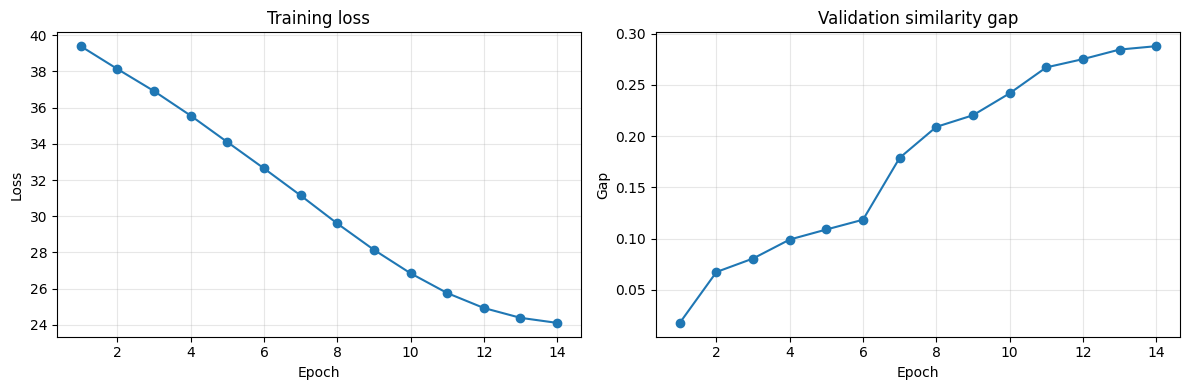

In [6]:
client = mlflow.MlflowClient()

loss_points = client.get_metric_history(training_result.run_id, 'train/loss')
gap_points = client.get_metric_history(
    training_result.run_id, 'validation/similarity_gap'
)

training_history = pd.DataFrame({
    'epoch': [point.step for point in loss_points],
    'train_loss': [point.value for point in loss_points],
    'validation_similarity_gap': [point.value for point in gap_points],
})
display(training_history.round(4))

training_figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(training_history['epoch'], training_history['train_loss'], marker='o')
axes[0].set(title='Training loss', xlabel='Epoch', ylabel='Loss')
axes[0].grid(alpha=0.3)
axes[1].plot(
    training_history['epoch'],
    training_history['validation_similarity_gap'],
    marker='o',
)
axes[1].set(title='Validation similarity gap', xlabel='Epoch', ylabel='Gap')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Validation and test evaluation

The verification threshold is selected only on the validation set. The test set uses the same threshold and does not affect its selection.

Evaluation:   0%|          | 0/318 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/317 [00:00<?, ?it/s]

,validation,test
threshold,0.1881,0.1881
accuracy,0.6837,0.6858
precision,0.6438,0.6365
recall_tar,0.8224,0.8666
f1,0.7222,0.7339
far,0.4551,0.4949
frr,0.1776,0.1334
roc_auc,0.7301,0.7339
eer,0.3337,0.3259
genuine_similarity_mean,0.4973,0.5376


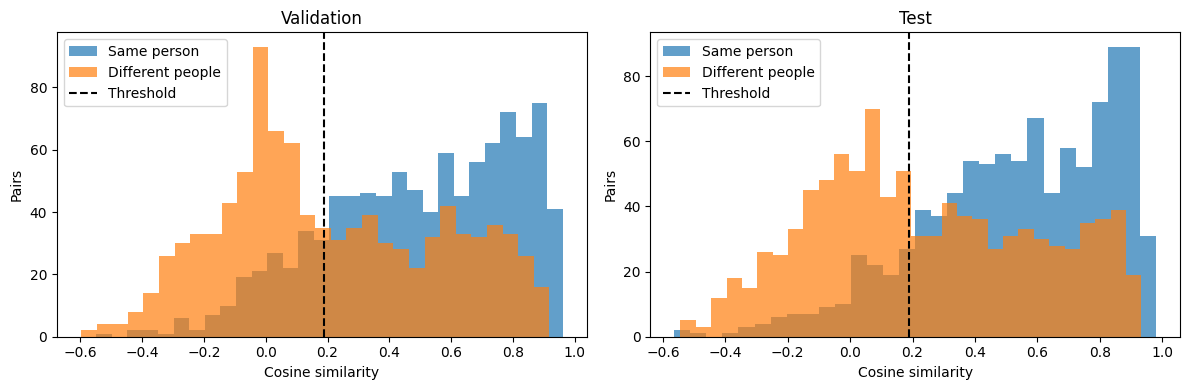

In [7]:
common_evaluation = {
    'checkpoint_path': training_result.checkpoint_path,
    'dataset_root': CELEBA_RAW_DIR,
    'batch_size': 64,
    'num_workers': 0,
    'device': 'cuda',
}

validation_result = evaluate_checkpoint(
    EvaluationConfig(
        manifest_path=CELEBA_MANIFESTS_DIR / 'validation.csv',
        **common_evaluation,
    )
)
test_result = evaluate_checkpoint(
    EvaluationConfig(
        manifest_path=CELEBA_MANIFESTS_DIR / 'test.csv',
        **common_evaluation,
    ),
    threshold=validation_result.threshold,
)

evaluation_table = pd.DataFrame({
    'validation': validation_result.metrics,
    'test': test_result.metrics,
})
display(evaluation_table.round(4))

scores_figure, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, name, result in zip(
    axes,
    ['Validation', 'Test'],
    [validation_result, test_result],
):
    axis.hist(result.genuine_scores, bins=30, alpha=0.7, label='Same person')
    axis.hist(result.impostor_scores, bins=30, alpha=0.7, label='Different people')
    axis.axvline(validation_result.threshold, color='black', linestyle='--', label='Threshold')
    axis.set(title=name, xlabel='Cosine similarity', ylabel='Pairs')
    axis.legend()
plt.tight_layout()
plt.show()

## 7. Save the model and results to Google Drive

In [8]:
import shutil

RUN_DIR = RESULTS_DIR / training_result.run_id
RUN_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy2(training_result.checkpoint_path, RUN_DIR / 'model.pt')
training_history.to_csv(RUN_DIR / 'training_history.csv', index=False)
evaluation_table.to_csv(RUN_DIR / 'evaluation_metrics.csv')
training_figure.savefig(RUN_DIR / 'training_history.png', bbox_inches='tight')
scores_figure.savefig(RUN_DIR / 'score_distributions.png', bbox_inches='tight')

print('Saved results:', RUN_DIR)
for path in sorted(RUN_DIR.iterdir()):
    print('-', path.name)

Saved results: /content/drive/MyDrive/face-recognition-results/d3f10f3fd1df49b69c7d041965b45110
- evaluation_metrics.csv
- model.pt
- score_distributions.png
- training_history.csv
- training_history.png


## Metric summary

- `train_loss`: should generally decrease.
- `validation_similarity_gap`: difference between same-person and different-person similarity; higher is better.
- `accuracy`, `f1`, `roc_auc`: higher is better.
- `far`: proportion of different people incorrectly accepted; lower is better.
- `frr`: proportion of correct people incorrectly rejected; lower is better.
- `eer`: balance between FAR and FRR; lower is better.